I. Set up

In [74]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
import shap
warnings.filterwarnings("ignore")


II. Methodology

1. Load the dataset

In [75]:
# Load the dataset
df = pd.read_csv("../data/diabetes_data_clean_v2.csv")
print("Shape:", df.shape)
print(df["diabetes_class"].value_counts(), "\n")

features = [c for c in df.columns if c != "diabetes_class"]
X = df[features].values
y = df["diabetes_class"].values

Shape: (520, 17)
diabetes_class
1    320
0    200
Name: count, dtype: int64 



2. Construct all classifiers

In [76]:
# Naive Bayes
nb_model = BernoulliNB()
# Logistic Regression
lr_model = LogisticRegression(penalty = None, random_state = 4308)
# Decision Tree
dt_model = DecisionTreeClassifier(random_state = 4308)
# Random Forest
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 4308)
# XGBoost   
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=4308, eval_metric="logloss")

3. Evaluate

In [77]:
# Split train/test for hold-out evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4308, stratify=y)
# Cross-validation 
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=4308)
X_all = np.vstack([X_train, X_test])
y_all = np.hstack([y_train, y_test])

feature_names = [f"feature_{i}" for i in range(X.shape[1])]


In [78]:
def eval_model(model, name):
    """Train model, print 80/20 and 10-fold CV results."""
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    holdout_results = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs)}

    cv_results = {
        "accuracy": cross_val_score(model, X_all, y_all, cv=cv, scoring="accuracy").mean(),
        "precision": cross_val_score(model, X_all, y_all, cv=cv, scoring="precision").mean(),
        "recall": cross_val_score(model, X_all, y_all, cv=cv, scoring="recall").mean(),
        "f1": cross_val_score(model, X_all, y_all, cv=cv, scoring="f1").mean(),
        "roc_auc": cross_val_score(model, X_all, y_all, cv=cv, scoring="roc_auc").mean()}
    return model, preds, probs, holdout_results, cv_results

3.1. Model Performance

In [79]:
# Construct evaluation results for all models

# Naive Bayes
nb_eval = eval_model(nb_model, "Naive Bayes")
# Logistic Regression
lr_eval = eval_model(lr_model, "Logistic Regression")
# Decision Tree
dt_eval = eval_model(dt_model, "Decision Tree")
# Random Forest
rf_eval = eval_model(rf_model, "Random Forest")
# XGBoost   
xgb_eval = eval_model(xgb_model, "XGBoost")  

In [80]:
# Naive Bayes results
nb_model, nb_preds, nb_probs, nb_holdout_results, nb_cv_results = nb_eval
print("Naive Bayes results:")
print("Holdout results:")
for metric, score in nb_holdout_results.items():
    print(f"  {metric}: {score:.4f}")
print("10-fold CV results:")
for metric, score in nb_cv_results.items():
    print(f"  {metric}: {score:.4f}")


Naive Bayes results:
Holdout results:
  accuracy: 0.9135
  precision: 0.9508
  recall: 0.9062
  f1: 0.9280
  roc_auc: 0.9688
10-fold CV results:
  accuracy: 0.8750
  precision: 0.9352
  recall: 0.8594
  f1: 0.8915
  roc_auc: 0.9494


In [81]:
# Logistic Regression results
lr_model, lr_preds, lr_probs, lr_holdout_results, lr_cv_results = lr_eval
print("Logistic Regression results:")
print("Holdout results:")
for metric, score in lr_holdout_results.items():
    print(f"  {metric}: {score:.4f}")
print("10-fold CV results:")
for metric, score in lr_cv_results.items():
    print(f"  {metric}: {score:.4f}")

Logistic Regression results:
Holdout results:
  accuracy: 0.9327
  precision: 0.9130
  recall: 0.9844
  f1: 0.9474
  roc_auc: 0.9844
10-fold CV results:
  accuracy: 0.9231
  precision: 0.9460
  recall: 0.9313
  f1: 0.9374
  roc_auc: 0.9712


In [82]:
# Decision Tree results
dt_model, dt_preds, dt_probs, dt_holdout_results, dt_cv_results = dt_eval
print("Decision Tree results:")
print("Holdout results:")
for metric, score in dt_holdout_results.items():
    print(f"  {metric}: {score:.4f}")
print("10-fold CV results:")
for metric, score in dt_cv_results.items():
    print(f"  {metric}: {score:.4f}")   

Decision Tree results:
Holdout results:
  accuracy: 0.9327
  precision: 0.9672
  recall: 0.9219
  f1: 0.9440
  roc_auc: 0.9359
10-fold CV results:
  accuracy: 0.9635
  precision: 0.9757
  recall: 0.9656
  f1: 0.9696
  roc_auc: 0.9628


In [83]:
# Random Forest results
rf_model, rf_preds, rf_probs, rf_holdout_results, rf_cv_results = rf_eval
print("Random Forest results:")
print("Holdout results:")
for metric, score in rf_holdout_results.items():
    print(f"  {metric}: {score:.4f}")
print("10-fold CV results:")
for metric, score in rf_cv_results.items():
    print(f"  {metric}: {score:.4f}")

Random Forest results:
Holdout results:
  accuracy: 0.9712
  precision: 0.9552
  recall: 1.0000
  f1: 0.9771
  roc_auc: 0.9988
10-fold CV results:
  accuracy: 0.9808
  precision: 0.9878
  recall: 0.9812
  f1: 0.9840
  roc_auc: 0.9981


In [84]:
# XGBoost results
xgb_model, xgb_preds, xgb_probs, xgb_holdout_results, xgb_cv_results = xgb_eval
print("XGBoost results:")
print("Holdout results:")
for metric, score in xgb_holdout_results.items():
    print(f"  {metric}: {score:.4f}")
print("10-fold CV results:")
for metric, score in xgb_cv_results.items():
    print(f"  {metric}: {score:.4f}")

XGBoost results:
Holdout results:
  accuracy: 0.9904
  precision: 1.0000
  recall: 0.9844
  f1: 0.9921
  roc_auc: 0.9980
10-fold CV results:
  accuracy: 0.9692
  precision: 0.9876
  recall: 0.9625
  f1: 0.9738
  roc_auc: 0.9922


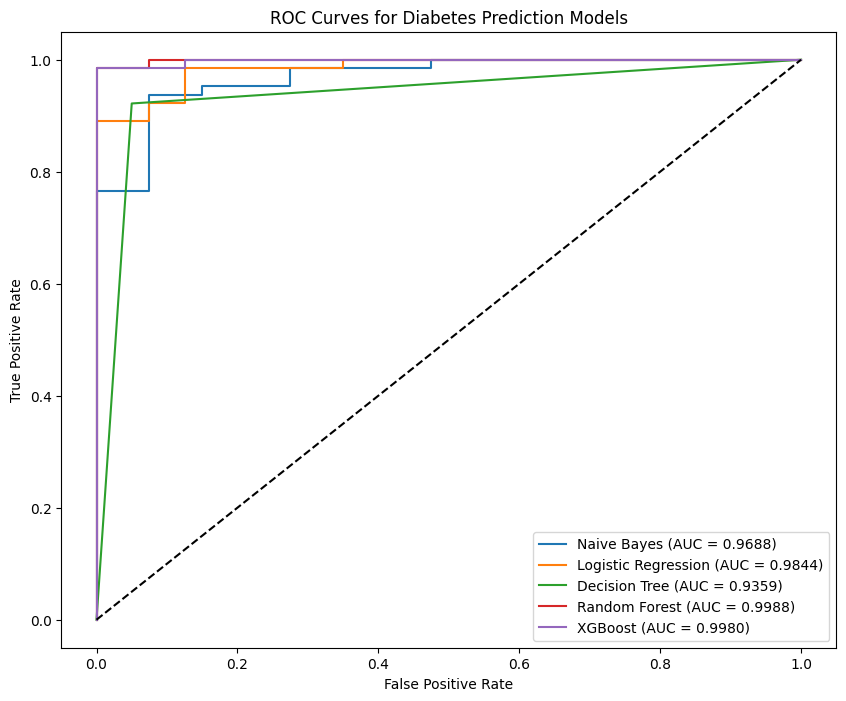

In [85]:
# ROC curves for all models in hold-out evaluation
plt.figure(figsize=(10, 8))
models = [("Naive Bayes", nb_probs), ("Logistic Regression", lr_probs), ("Decision Tree", dt_probs), 
          ("Random Forest", rf_probs), ("XGBoost", xgb_probs)]
for name, probs in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, probs):.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Diabetes Prediction Models")
plt.legend(loc="lower right")
plt.show()

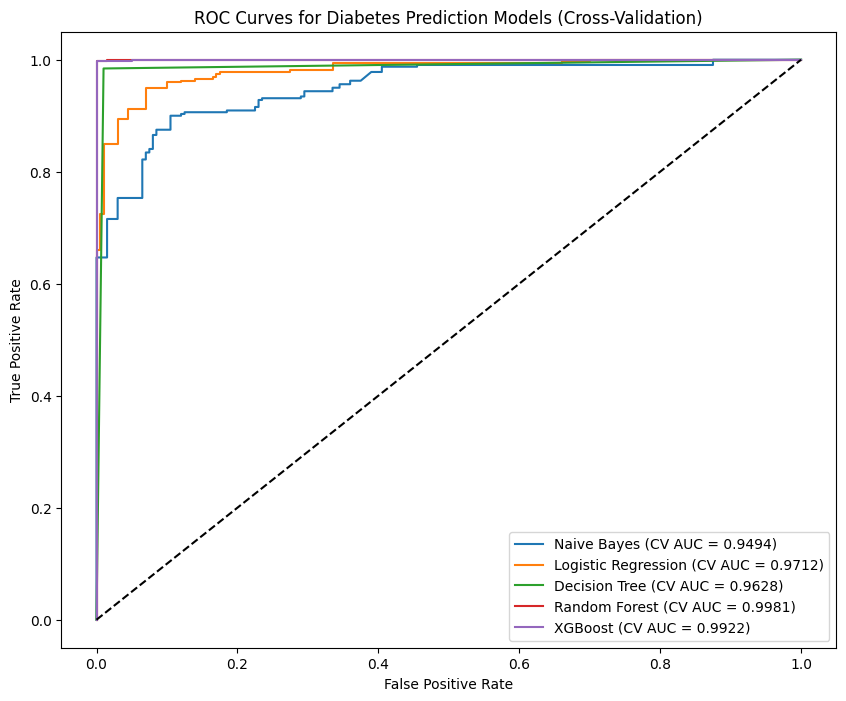

In [86]:
# ROC curves for all models in cross-validation
plt.figure(figsize=(10, 8))
for name, eval in [("Naive Bayes", nb_eval), ("Logistic Regression", lr_eval), ("Decision Tree", dt_eval), 
                   ("Random Forest", rf_eval), ("XGBoost", xgb_eval)]:
    model, _, _, _, cv_results = eval
    probs = model.predict_proba(X_all)[:, 1]
    fpr, tpr, _ = roc_curve(y_all, probs)
    plt.plot(fpr, tpr, label=f"{name} (CV AUC = {cv_results['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Diabetes Prediction Models (Cross-Validation)")
plt.legend(loc="lower right")
plt.show()

3.2. Learning Curves

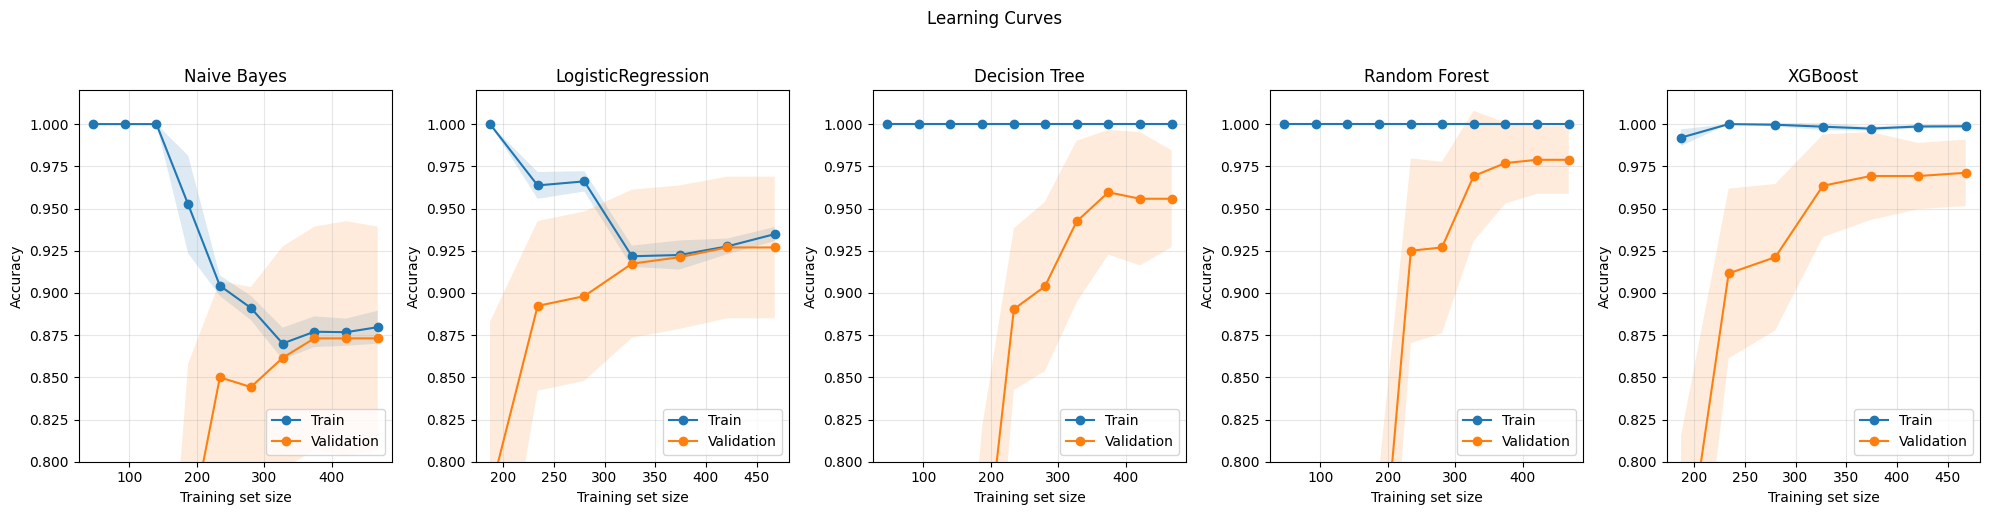

In [87]:
models = {
    "Naive Bayes": nb_model,
    "LogisticRegression": lr_model,
     "Decision Tree": dt_model,
     "Random Forest": rf_model,
     "XGBoost": xgb_model
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (name, model) in zip(axes, models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy")

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", label="Train")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    ax.plot(train_sizes, val_mean, "o-", label="Validation")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    ax.set_title(name)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.8, 1.02)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning Curves", y=1.02)
plt.tight_layout()
plt.show()

3.3 SHAP

In [88]:
features

['gender',
 'polyuria',
 'polydipsia',
 'sudden_weight_loss',
 'weakness',
 'polyphagia',
 'genital_thrush',
 'visual_blurring',
 'itching',
 'irritability',
 'delayed_healing',
 'partial_paresis',
 'muscle_stiffness',
 'alopecia',
 'obesity',
 'age_scaled']

In [89]:
def compute_shap_values(model, X_train, y_train, X_test):
    """Compute SHAP values for a given model."""
    
    model.fit(X_train, y_train)
    if model.__class__.__name__ == "BernoulliNB":
        predict_fn = model.predict_proba
        explainer = shap.KernelExplainer(predict_fn, X_train)

    
    elif model.__class__.__name__ == "LogisticRegression":
        predict_fn = model
        explainer = shap.LinearExplainer(predict_fn, X_train)

        
    elif model.__class__.__name__ == "DecisionTreeClassifier":
        predict_fn = model
        explainer = shap.TreeExplainer(predict_fn, X_train)

    else:
        predict_fn = model
        explainer = shap.TreeExplainer(predict_fn, X_train)

    sv_raw = explainer(X_test)
    sv = sv_raw[:, :, 1] if sv_raw.values.ndim == 3 else sv_raw
    baseline = explainer.expected_value[1] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value
    sv = shap.Explanation(values=sv.values, base_values=baseline, data=X_test, feature_names=features)     

    return sv


In [ ]:
# Naive Bayes SHAP values
nb_sv = compute_shap_values(nb_model, X_train, y_train, X_test)
# Logistic Regression SHAP values
lr_sv = compute_shap_values(lr_model, X_train, y_train, X_test)
# Decision Tree SHAP values
dt_sv = compute_shap_values(dt_model, X_train, y_train, X_test)
# Random Forest SHAP values
rf_sv = compute_shap_values(rf_model, X_train, y_train, X_test)
# XGBoost SHAP values
xgb_sv = compute_shap_values(xgb_model, X_train, y_train, X_test)

Using 416 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
 52%|█████▏    | 54/104 [00:21<00:20,  2.40it/s]

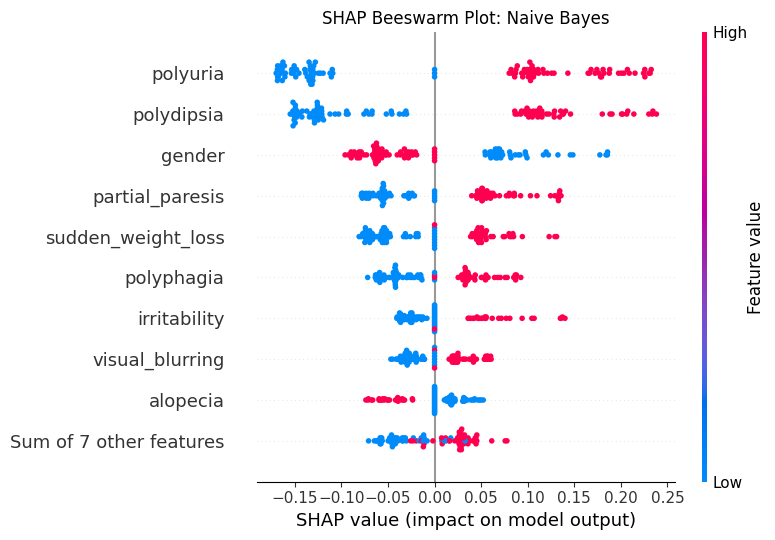

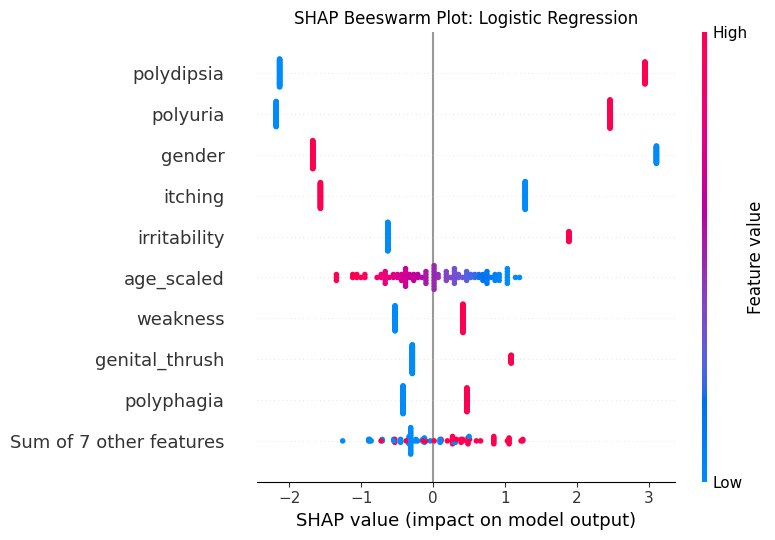

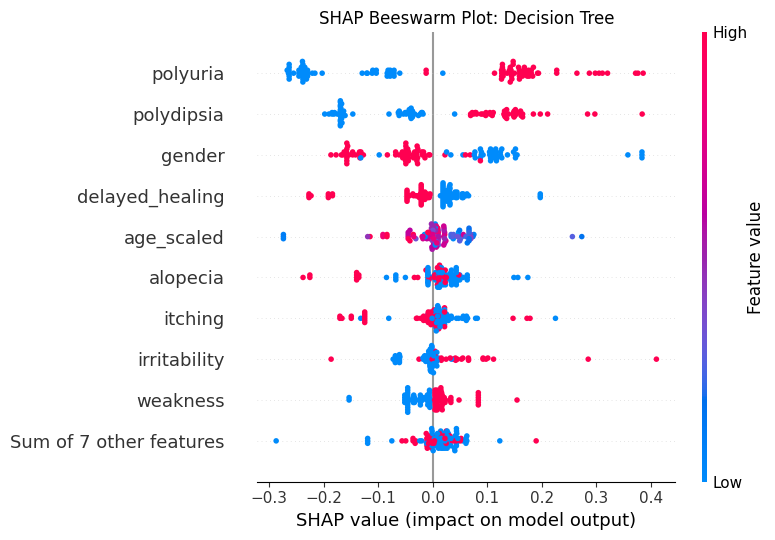

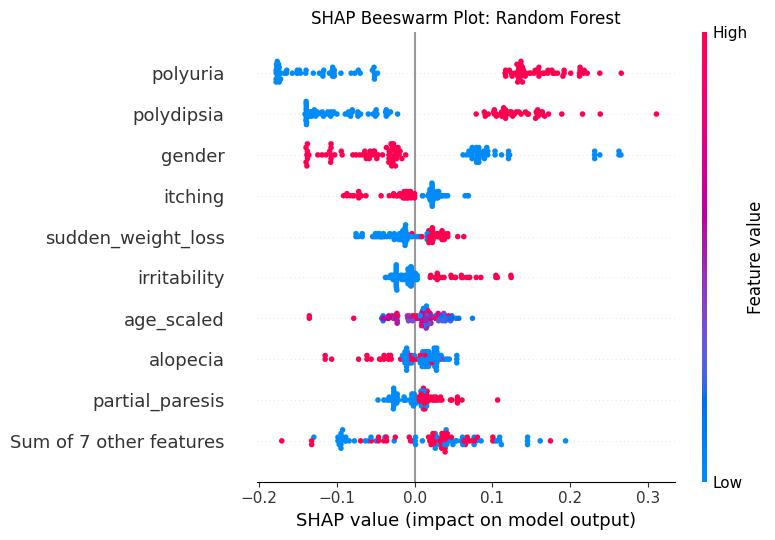

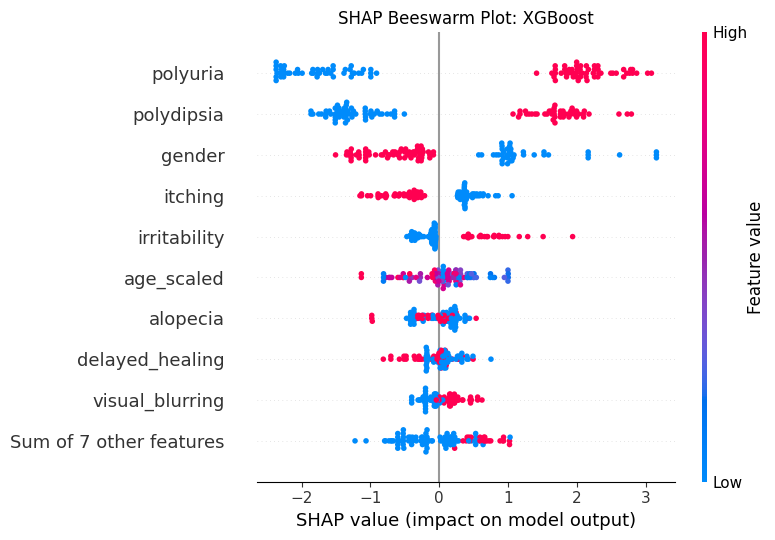

In [ ]:
# Beeswarm plots for all models
sv_values = {"Naive Bayes": nb_sv, "Logistic Regression": lr_sv, "Decision Tree": dt_sv,
             "Random Forest": rf_sv, "XGBoost": xgb_sv}


for name, sv in sv_values.items():
    plt.figure(figsize=(6, 4))
    shap.plots.beeswarm(sv, show=False)
    plt.title(f"SHAP Beeswarm Plot: {name}")
    plt.tight_layout()
    plt.show()

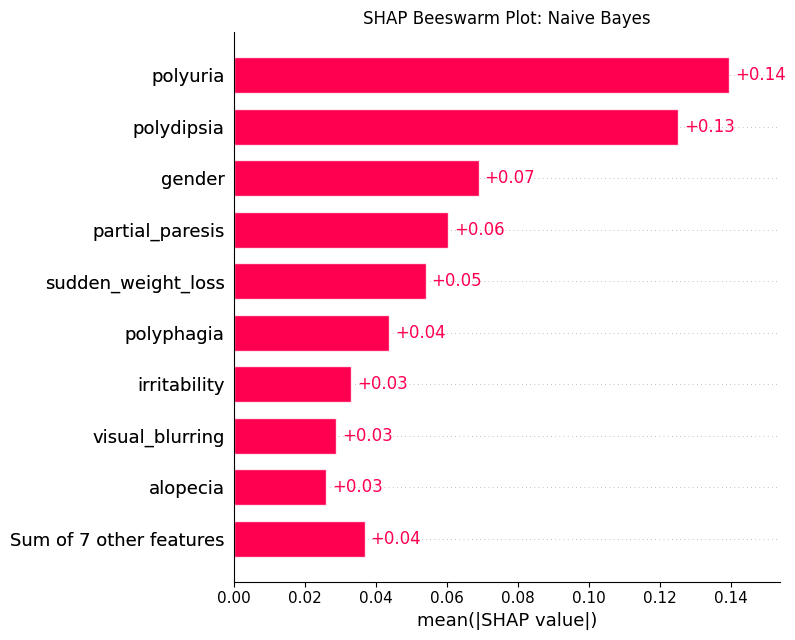

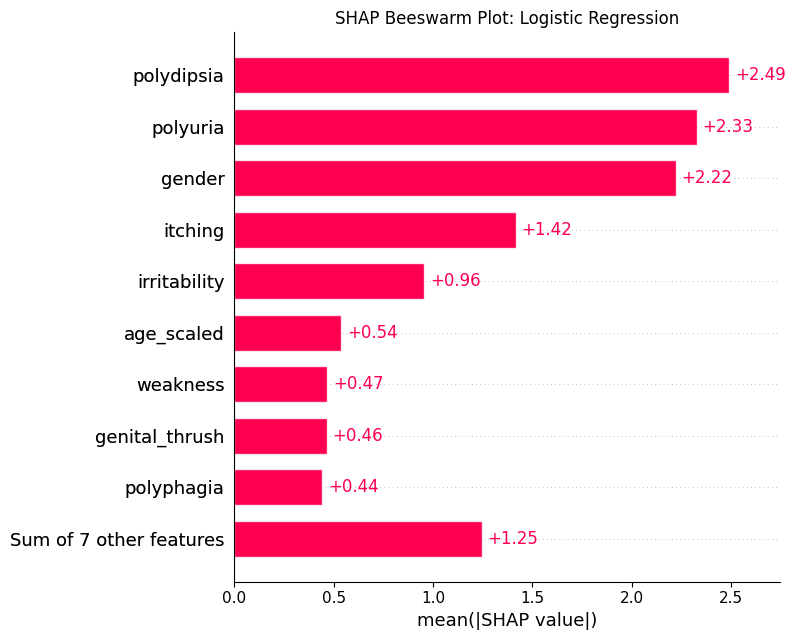

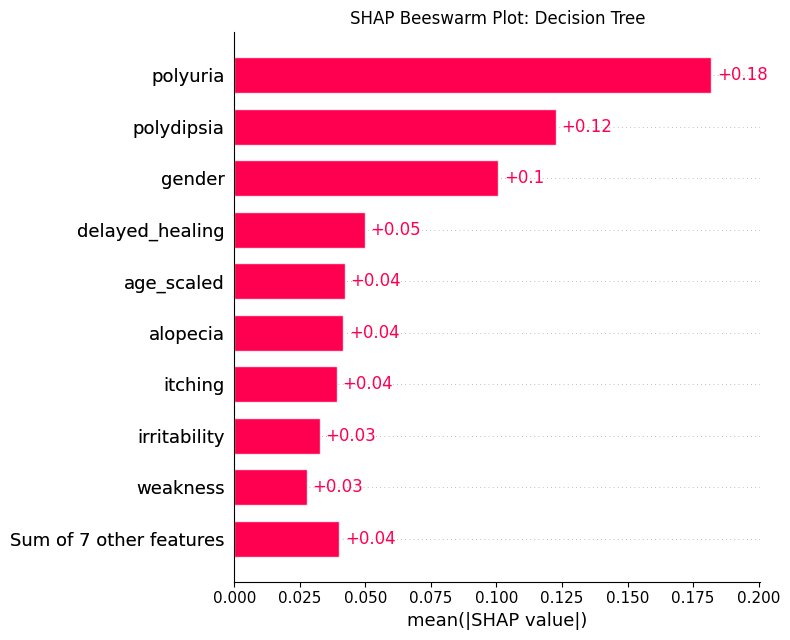

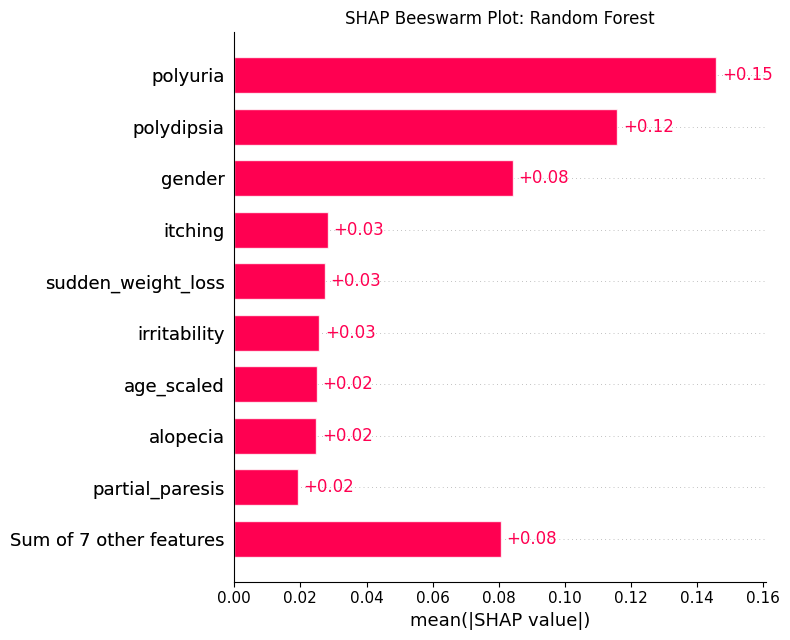

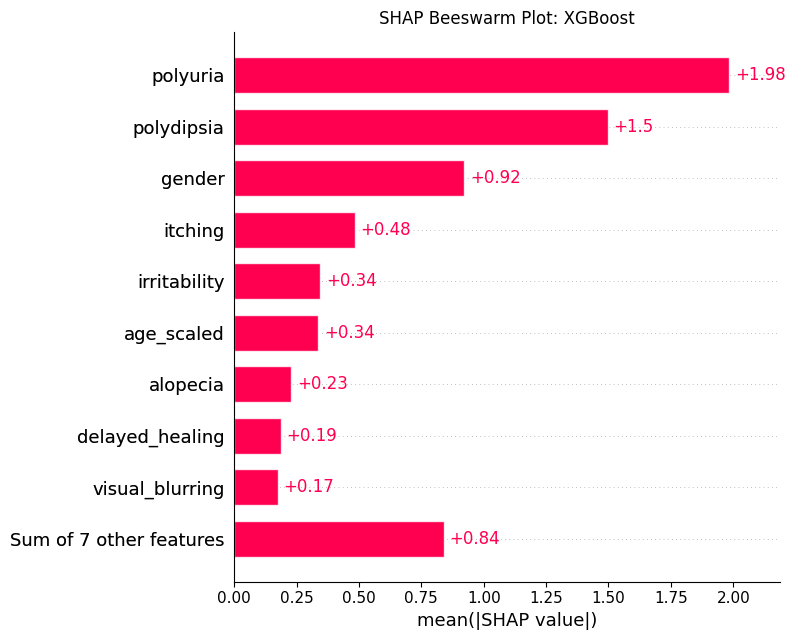

In [ ]:
# Bar plots for all models
for name, sv in sv_values.items():
    plt.figure(figsize=(6, 4))
    shap.plots.bar(sv, show=False)
    plt.title(f"SHAP Beeswarm Plot: {name}")
    plt.tight_layout()
    plt.show()